In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

%matplotlib inline
print("Libraries Imported!")

Libraries Imported!


In [2]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['target'] = housing.target

print(df.shape)
print(df.head())

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

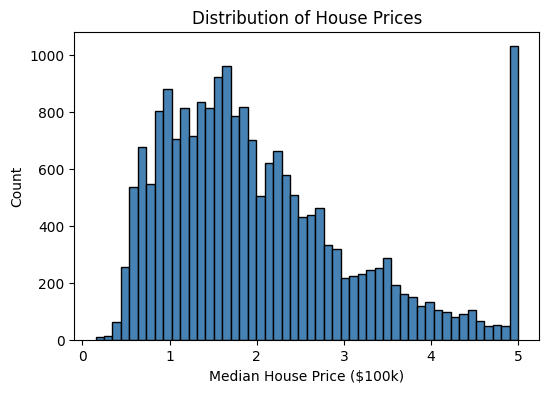

In [4]:
plt.figure(figsize=(6, 4))
plt.hist(df['target'], bins=50, color="steelblue", edgecolor="black")
plt.title('Distribution of House Prices')
plt.xlabel('Median House Price ($100k)')
plt.ylabel('Count')
plt.show()

In [5]:
df = df[df['target'] < 5.0].reset_index(drop=True)
print(df.shape)
print(df['target'].max())

(19648, 9)
4.991


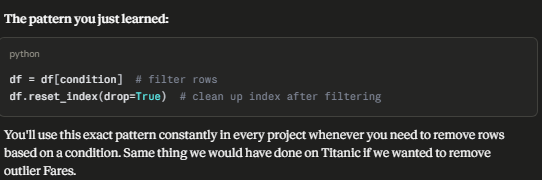

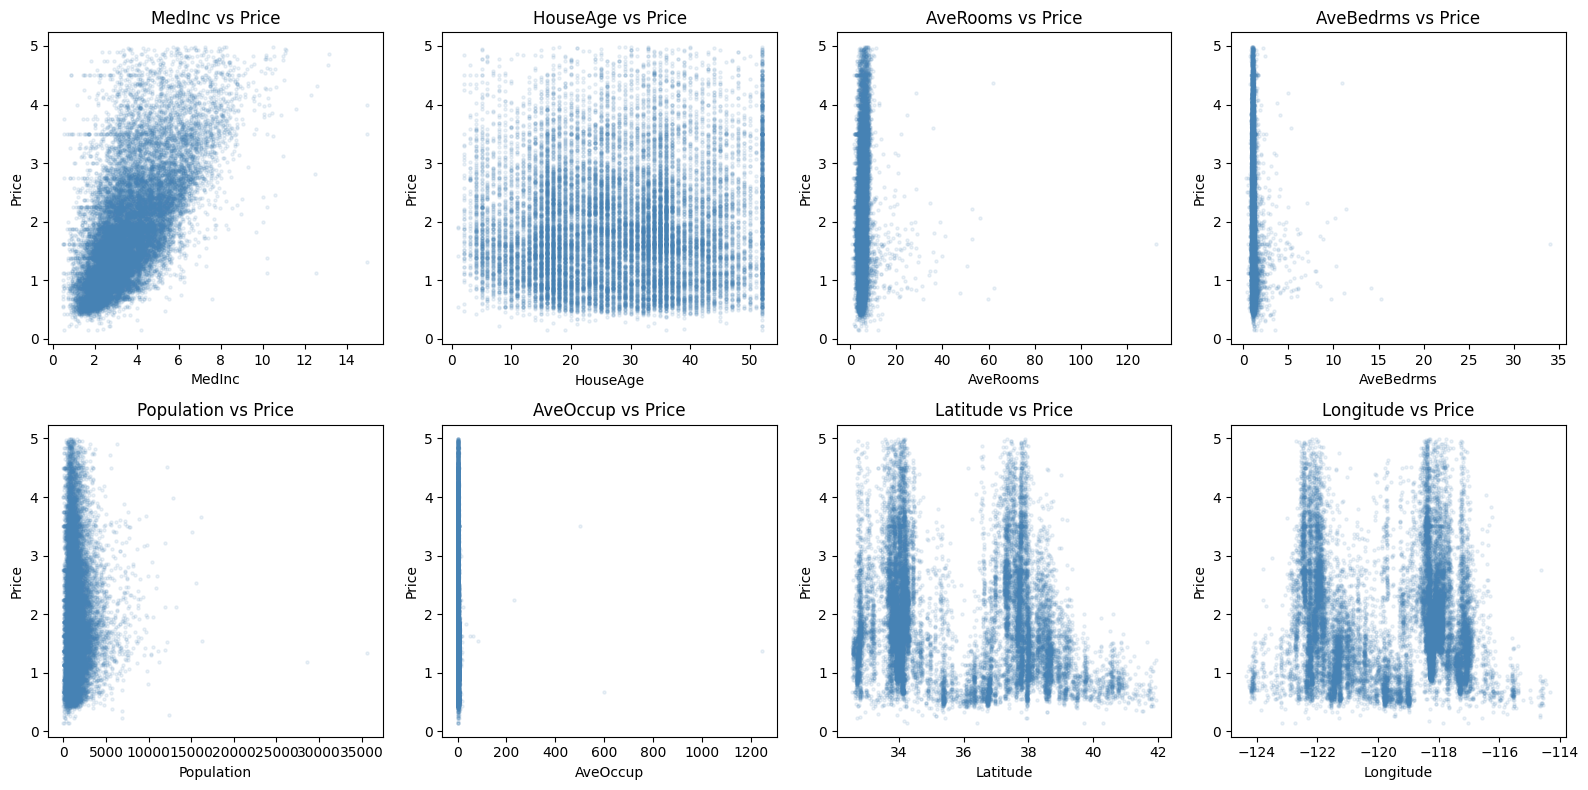

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

features = housing.feature_names

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['target'], alpha=0.1, s=5, color='steelblue')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Price')
    axes[i].set_title(f'{feature} vs Price')

plt.tight_layout()
plt.show()

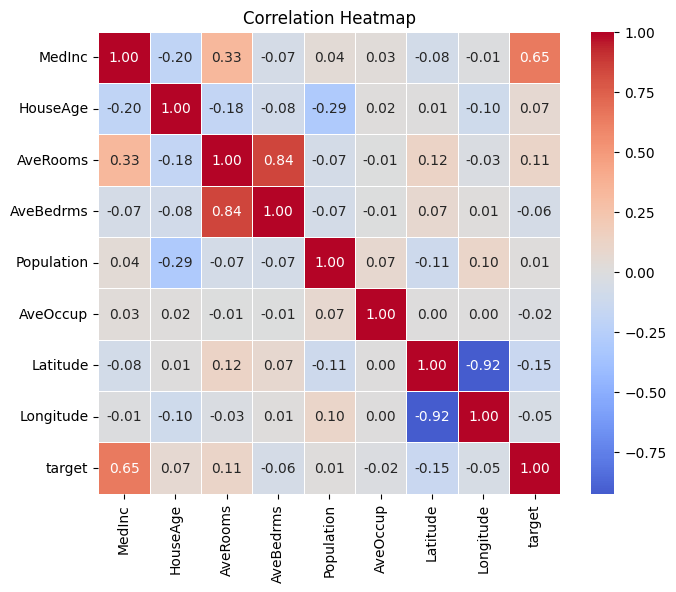

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

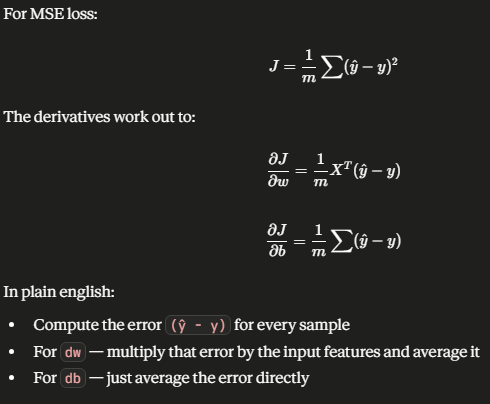

In [8]:
X = df.drop('target', axis=1).values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)

(15718, 8)
(3930, 8)
(15718,)


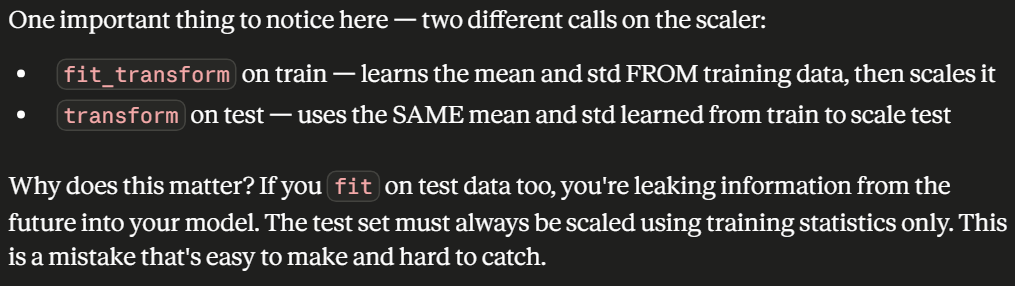

In [9]:
class LinearRegressionScratch:
    
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.w = None
        self.b = None
        self.loss_history = []
    
    def forward(self, X):
        # ŷ = Xw + b
        return X @ self.w + self.b
    
    def compute_loss(self, y_pred, y_true):
        # MSE = (1/m) * sum((ŷ - y)²)
        m = len(y_true)
        return (1/m) * np.sum((y_pred - y_true) ** 2)
    
    def compute_gradients(self, X, y_pred, y_true):
        m = len(y_true)
        error = y_pred - y_true                    # (m,)
        dw = (1/m) * X.T @ error                   # (8,)
        db = (1/m) * np.sum(error)                 # scalar
        return dw, db
    
    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)   # initialise weights to 0
        self.b = 0.0           # initialise bias to 0
        
        for epoch in range(self.epochs):
            # Forward pass
            y_pred = self.forward(X)
            
            # Compute loss
            loss = self.compute_loss(y_pred, y)
            self.loss_history.append(loss)
            
            # Compute gradients
            dw, db = self.compute_gradients(X, y_pred, y)
            
            # Update parameters
            self.w = self.w - self.lr * dw
            self.b = self.b - self.lr * db
            
            # Print every 100 epochs
            if epoch % 100 == 0:
                print(f"Epoch {epoch} | Loss: {loss:.4f}")
    
    def predict(self, X):
        return self.forward(X)

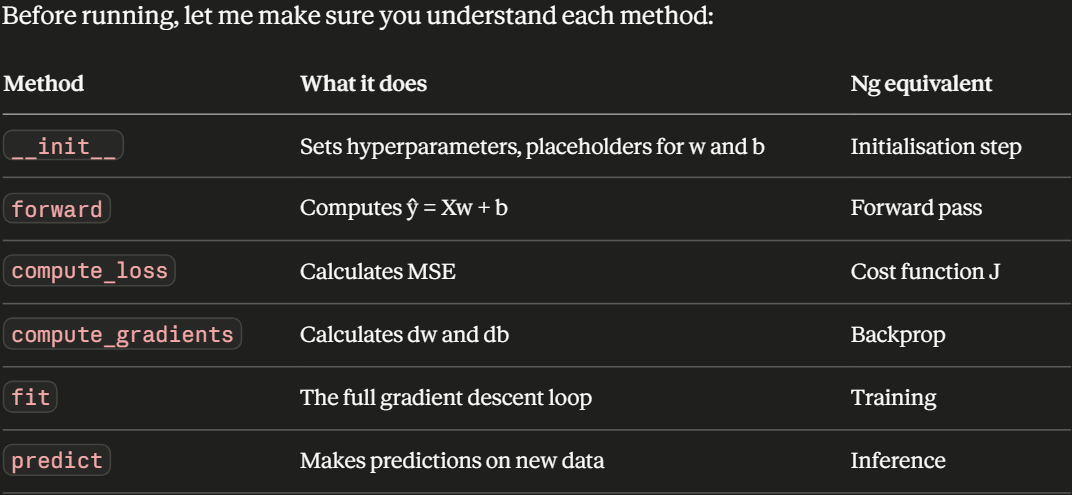

In [10]:
# Train the model
model = LinearRegressionScratch(learning_rate=0.1, epochs=1000)
model.fit(X_train, y_train)

Epoch 0 | Loss: 4.6275
Epoch 100 | Loss: 0.4211
Epoch 200 | Loss: 0.4035
Epoch 300 | Loss: 0.3998
Epoch 400 | Loss: 0.3989
Epoch 500 | Loss: 0.3987
Epoch 600 | Loss: 0.3986
Epoch 700 | Loss: 0.3986
Epoch 800 | Loss: 0.3985
Epoch 900 | Loss: 0.3985


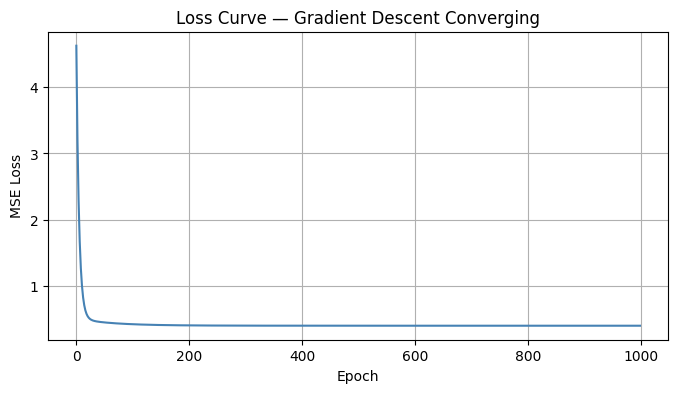

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(model.loss_history, color='steelblue')
plt.title('Loss Curve — Gradient Descent Converging')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

In [12]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}  (${rmse * 100_000:,.0f})")
print(f"R²:   {r2:.4f}")

MSE:  0.4133
RMSE: 0.6428  ($64,285)
R²:   0.5690


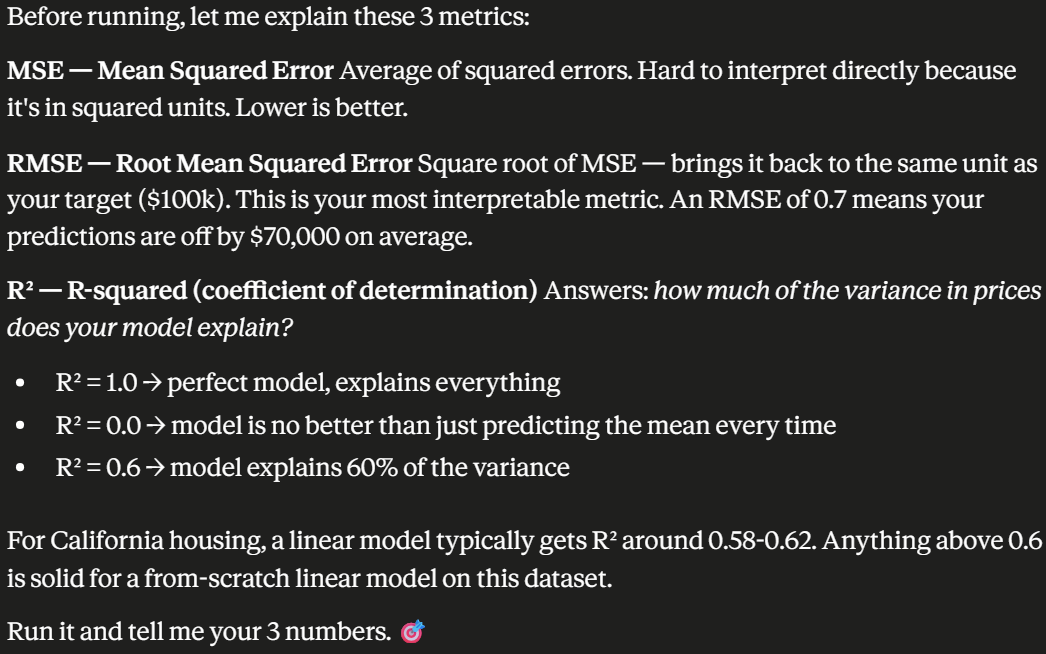

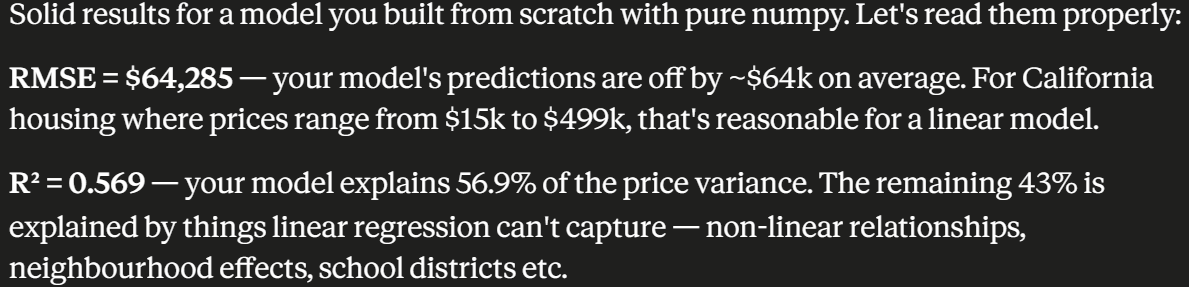

# Prove yours works by comparing to sklearn

In [13]:
from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)
sklearn_pred = sklearn_model.predict(X_test)

sklearn_rmse = np.sqrt(mean_squared_error(y_test, sklearn_pred))
sklearn_r2 = r2_score(y_test, sklearn_pred)

print("=== YOUR MODEL ===")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

print("\n=== SKLEARN MODEL ===")
print(f"RMSE: {sklearn_rmse:.4f}")
print(f"R²:   {sklearn_r2:.4f}")

=== YOUR MODEL ===
RMSE: 0.6428
R²:   0.5690

=== SKLEARN MODEL ===
RMSE: 0.6429
R²:   0.5689


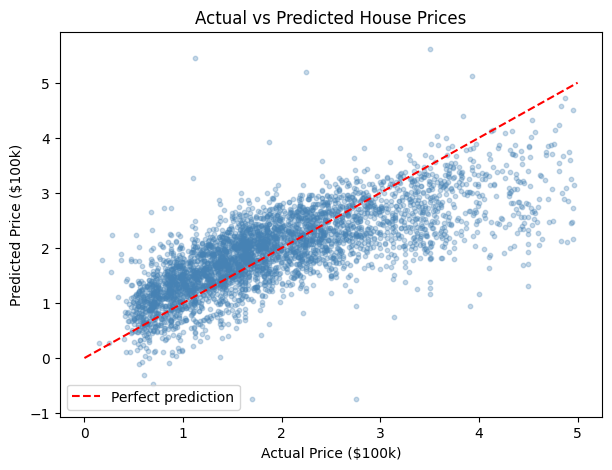

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
plt.plot([0, 5], [0, 5], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Price ($100k)')
plt.ylabel('Predicted Price ($100k)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.show()

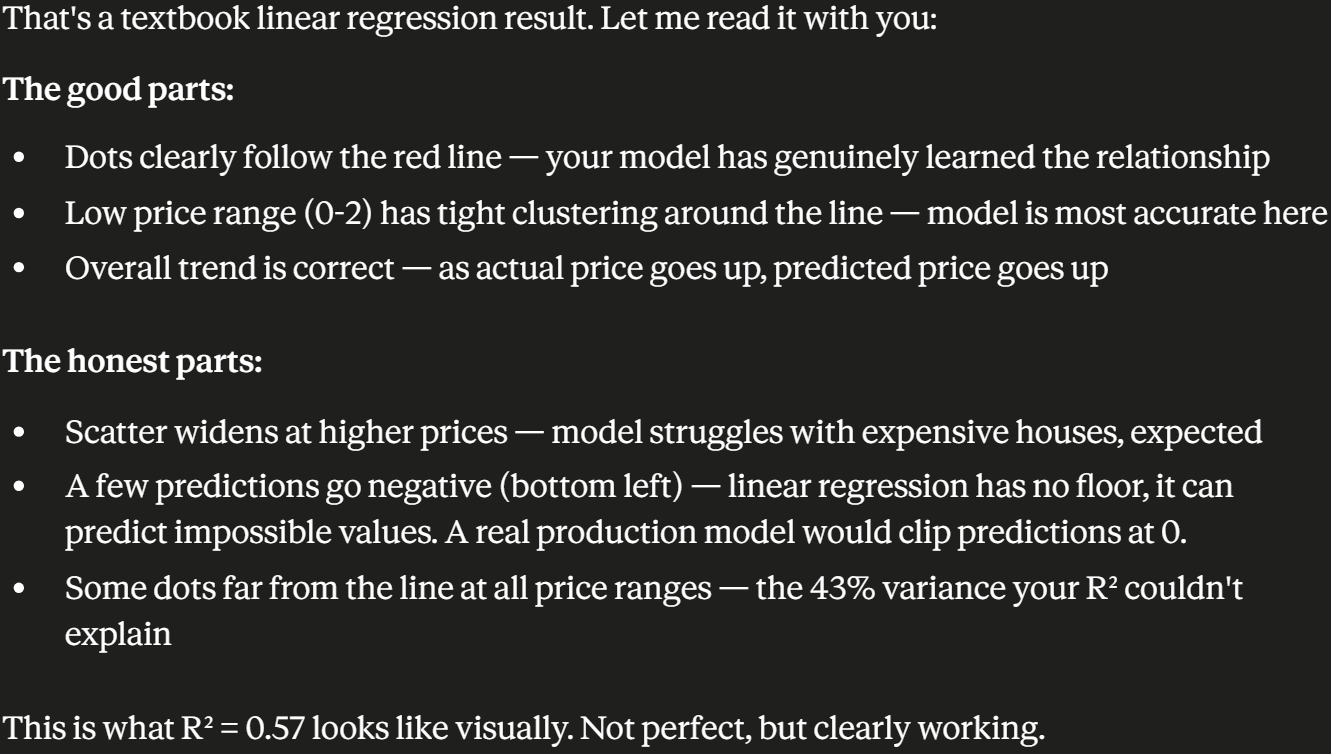

In [15]:
import joblib

joblib.dump({'w': model.w, 'b': model.b}, '../housing_model.pkl')
joblib.dump(scaler, '../housing_scaler.pkl')

print("Model and Scaler Saved!")

Model and Scaler Saved!


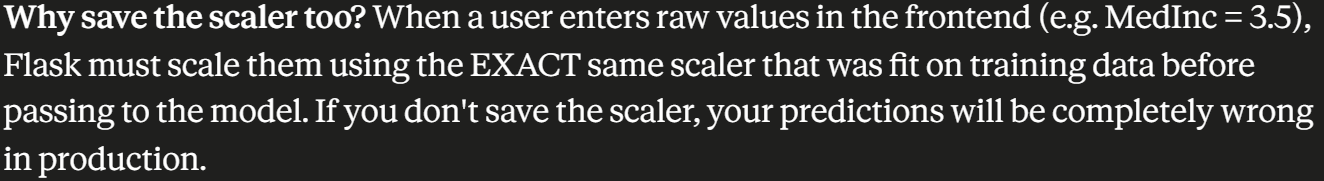